# Somalia workflow: Step 2: Flood benchmark (Floodscan SFED vs SWALIM)

Adaptation of the NGA 2026 state-parameterized trigger workflow
(`ds-aa-nga-flooding/exploration/2026/cerf/workflow/02_floodscan_benchmark.ipynb`)
to the Juba and Shabelle. This step builds the historical flood benchmark that
all later steps (gauge correlation, gauge selection, trigger grid search) key
off.

Differences from Nigeria, by necessity:

1. **Two wet seasons**: Gu (MAM) and Deyr (OND) are benchmarked separately
   (NGA has a single Aug-Nov season).
2. **Somalia has river gauges; Nigeria effectively didn't.** SWALIM observed
   levels give a second historical record, so this step validates Floodscan
   *against* the gauges before it is trusted as ground truth: the
   two-historical-records requirement in `ds-knowledge-base/methods/trigger-design.md`.

**Inputs** (blob, built 2026-08-04):
- `ds-aa-som-floods/processed/workflow/som_floodscan_daily.parquet`: daily
  mean SFED 1998-2023 per river x segment, from the global 300-arc-second
  SFED historical archive over 10-km buffers of the TDX main stems clipped
  to Somalia (segments split at lat 3.4/2.2 on the Shabelle, 2.0 on the Juba).
- `ds-aa-som-floods/processed/workflow/som_river_buffers.gpkg`: the buffers.
- `ds-aa-som-floods/processed/swalim_levels.parquet` + thresholds.

**Outputs**: `som_flood_benchmark_seasonal.parquet`: per (river, segment,
benchmark source, season, year): max value, Weibull RP, event flags at
RP >= 3/4/5.

In [1]:
import sys

sys.path.insert(0, "..")

import os
import tempfile
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
import ocha_stratus as stratus
import geopandas as gpd, tempfile, os

from src.constants import (
    SEASONS,
    SEASON_MONTHS,
    EXP_SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_MOD,
    C_HIGH,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_ISOL,
    C_JOINT,
    C_BAND,
    C_BAND_EDGE,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    C_SWALIM,
    C_SFED,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import (
    auc,
    episodes,
    gumbel_rp,
    hits,
    weibull_level,
    weibull_threshold,
    yT,
)

apply_chart_style()


In [2]:
def load(name):
    return stratus.load_parquet_from_blob(f"ds-aa-som-floods/processed/{name}.parquet", stage="dev")

fs = load("workflow/som_floodscan_daily")
fs["date"] = pd.to_datetime(fs["date"])
lv = load("swalim_levels")
lv["date"] = pd.to_datetime(lv["date"])

YEARS = (1998, 2023)   # SFED historical archive extent
RP_LEVELS = [3, 4, 5]
# gauges representing each river reach for the SWALIM benchmark
GAUGES = {("shabelle", "upper"): "belet_weyne", ("shabelle", "mid"): "jowhar",
          ("juba", "upper"): "luuq", ("juba", "lower"): "bardheere"}
print(f"SFED series: {fs.river.nunique()} rivers x {fs.segment.nunique()} segments, "
      f"{fs.date.min().date()} -> {fs.date.max().date()}")


SFED series: 2 rivers x 4 segments, 1998-01-12 -> 2023-12-31


## Station map

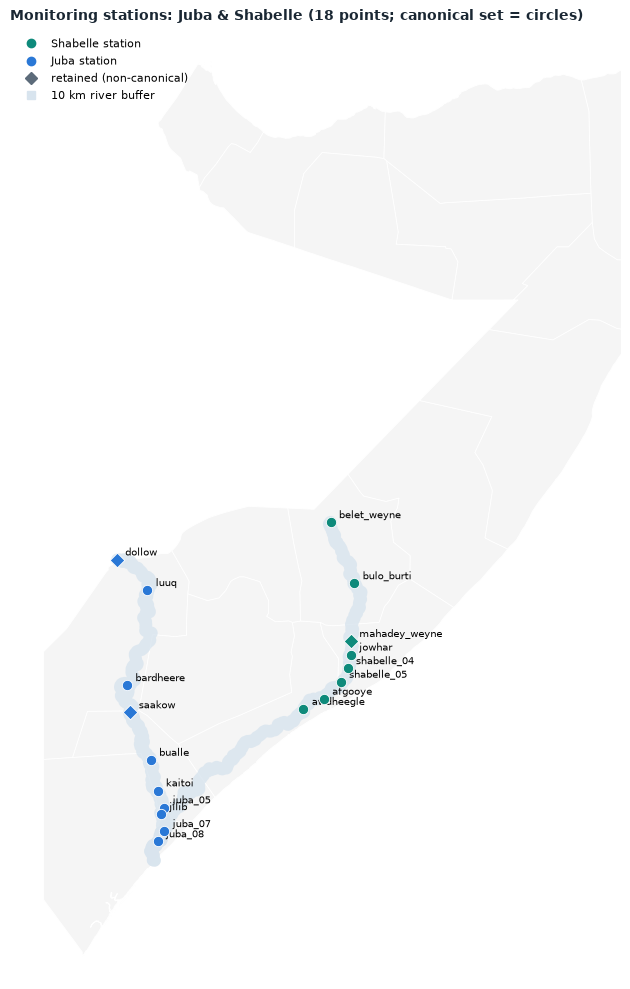

In [3]:
# admin boundaries + river buffers for context
adm1 = stratus.codab.load_codab_from_blob("som", admin_level=1)
_raw = stratus.load_blob_data("ds-aa-som-floods/processed/workflow/som_river_buffers.gpkg", stage="dev")
_tmp = os.path.join(tempfile.gettempdir(), "som_river_buffers.gpkg")
open(_tmp, "wb").write(_raw)
bufs = gpd.read_file(_tmp)

fig, ax = plt.subplots(figsize=(9, 10))
adm1.plot(ax=ax, color="#F5F5F5", edgecolor="white", linewidth=0.6)
bufs.plot(ax=ax, color="#D8E4EE", alpha=0.8)
RIVER_COLORS = {"shabelle": C_SHAB, "juba": C_JUBA}
for key, st in STATIONS.items():
    c = RIVER_COLORS[st.river]
    marker = "o" if st.canonical else "D"
    ax.scatter(st.lon, st.lat, color=c, marker=marker, s=55, zorder=5,
               edgecolors="white", linewidths=0.6)
    ax.annotate(key, (st.lon, st.lat), textcoords="offset points",
                xytext=(6, 3), fontsize=7)
handles = [
    plt.Line2D([], [], color=C_SHAB, marker="o", ls="", label="Shabelle station"),
    plt.Line2D([], [], color=C_JUBA, marker="o", ls="", label="Juba station"),
    plt.Line2D([], [], color=C_REF, marker="D", ls="", label="retained (non-canonical)"),
    plt.Line2D([], [], color="#D8E4EE", marker="s", ls="", label="10 km river buffer"),
]
ax.legend(handles=handles, loc="upper left", fontsize=8)
ax.set_xlim(40.5, 49.5); ax.set_ylim(-2, 12)
ax.set_title("Monitoring stations: Juba & Shabelle (18 points; canonical set = circles)", loc="left", fontsize=10)
ax.set_axis_off()
plt.tight_layout()


## Seasonality: the two flood seasons are clearly resolved

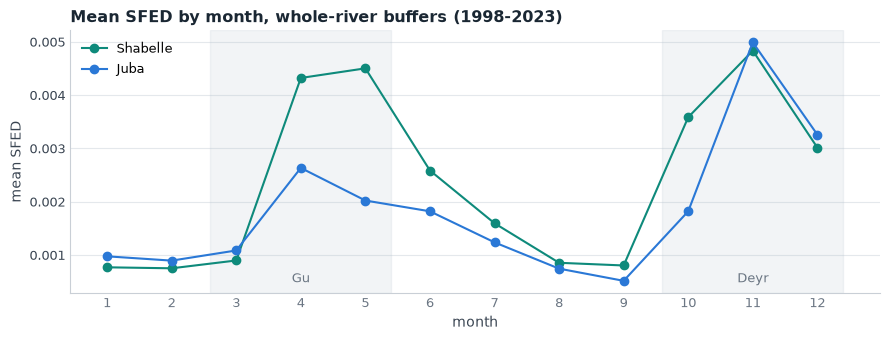

In [4]:
m = fs[fs.segment == "full"].assign(month=fs.date.dt.month).pivot_table(
    index="month", columns="river", values="mean_sfed", aggfunc="mean")
fig, ax = plt.subplots(figsize=(9, 3.5))
for riv_, color in [("shabelle", C_SHAB), ("juba", C_JUBA)]:
    ax.plot(m.index, m[riv_], marker="o", color=color, label=riv_.capitalize())
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for months, label in [((3, 5), "Gu"), ((10, 12), "Deyr")]:
    ax.axvspan(months[0] - 0.4, months[1] + 0.4, color="#B7C4CE", alpha=0.18)
    ax.text(
        (months[0] + months[1]) / 2,
        0.04,
        label,
        transform=trans,
        ha="center",
        fontsize=9,
        color=FAINT,
    )
ax.set_xticks(range(1, 13))
ax.set_xlabel("month")
ax.set_ylabel("mean SFED")
ax.set_title("Mean SFED by month, whole-river buffers (1998-2023)")
ax.legend()
style_ax(ax, grid="y")
plt.tight_layout()


## Seasonal annual maxima -> Weibull RP, every benchmark series

Weibull plotting position `RP = (n+1)/rank` (team standard,
`methods/return-periods.md`), computed per season over 1998-2023. SWALIM
series use the seasonal maximum observed level at the reach's reference
gauge, ranked the same way: plus the absolute Moderate Flood Risk
threshold as a second, count-based flag.

In [5]:
def seasonal_rp(series, months, y0=YEARS[0], y1=YEARS[1]):
    sub = series[series.index.month.isin(months)]
    sub = sub[(sub.index.year >= y0) & (sub.index.year <= y1)]
    am = sub.groupby(sub.index.year).max().dropna()
    if len(am) < 10:
        return None
    rp = (len(am) + 1) / am.rank(ascending=False)
    out = pd.DataFrame({"year": am.index, "max_value": am.values, "rp": rp.values})
    for lvl in RP_LEVELS:
        out[f"flood_{lvl}yr"] = (out["rp"] >= lvl).astype(int)
    return out

rows = []
for (riv, seg), grp in fs.groupby(["river", "segment"]):
    s = grp.set_index("date")["mean_sfed"]
    for season, months in SEASONS.items():
        r = seasonal_rp(s, months)
        if r is None:
            continue
        r["river"], r["segment"], r["season"], r["benchmark"] = riv, seg, season, "sfed"
        rows.append(r)
th = load("swalim_thresholds").set_index("station")
for (riv, seg), st in GAUGES.items():
    s = lv[lv.station == st].set_index("date")["level_m"]
    for season, months in SEASONS.items():
        r = seasonal_rp(s, months)
        if r is None:
            continue
        r["river"], r["segment"], r["season"], r["benchmark"] = riv, seg, season, f"swalim_{st}"
        thr = th.loc[st, "moderate_flood_risk"]
        if not np.isnan(thr):
            mx = s[s.index.month.isin(months)].groupby(lambda d: d.year).max()
            r["above_moderate"] = r["year"].map((mx >= thr).astype(int))
        rows.append(r)
bench = pd.concat(rows, ignore_index=True)
print(f"{len(bench)} rows across {bench.groupby(['benchmark','river','segment','season']).ngroups} series")


547 rows across 22 series


### Event years at >= 4-yr RP, side by side

(Comparison shown at 4-yr for contrast between benchmarks; the trigger
design in notebooks 08-10 uses the 3-yr event years.)

In [6]:
ev = (bench[bench.flood_4yr == 1]
      .groupby(["river", "segment", "benchmark", "season"])["year"]
      .apply(lambda y: sorted(y.tolist())))
ev.to_frame("event_years_4yr")


event_years_4yr
river    segment benchmark          season                                            
juba     full    sfed               deyr          [2002, 2006, 2011, 2013, 2014, 2023]
                                    gu            [2002, 2010, 2016, 2017, 2018, 2023]
         lower   sfed               deyr          [2000, 2006, 2011, 2014, 2017, 2023]
                                    gu            [2001, 2016, 2017, 2018, 2020, 2023]
                 swalim_bardheere   deyr                      [2006, 2008, 2014, 2023]
                                    gu                  [2005, 2018, 2020, 2021, 2023]
         upper   sfed               deyr          [2000, 2002, 2006, 2011, 2013, 2023]
                                    gu            [2002, 2004, 2010, 2016, 2018, 2023]
                 swalim_luuq        deyr          [2006, 2008, 2011, 2013, 2014, 2023]
                                    gu                  [2005, 2006, 2016, 2018, 2020]
shabelle full    sfed               deyr          [2004, 2011, 2015, 2016, 2017, 2023]
                                    gu            [2002, 2004, 2006, 2017, 2018, 2023]
         lower   sfed               deyr          [2004, 2016, 2017, 2019, 2021, 2023]
                                    gu            [2001, 2002, 2017, 2018, 2022, 2023]
         mid     sfed               deyr          [2004, 2011, 2014, 2015, 2017, 2023]
                                    gu            [2002, 2006, 2011, 2018, 2019, 2023]
                 swalim_jowhar      deyr          [2012, 2014, 2015, 2017, 2019, 2020]
                                    gu      [2002, 2003, 2012, 2013, 2015, 2016, 2020]
         upper   sfed               deyr          [2002, 2004, 2011, 2015, 2022, 2023]
                                    gu            [2000, 2002, 2004, 2006, 2015, 2023]
                 swalim_belet_weyne deyr                [2006, 2014, 2019, 2020, 2023]
                                    gu                  [2016, 2018, 2020, 2021, 2023]

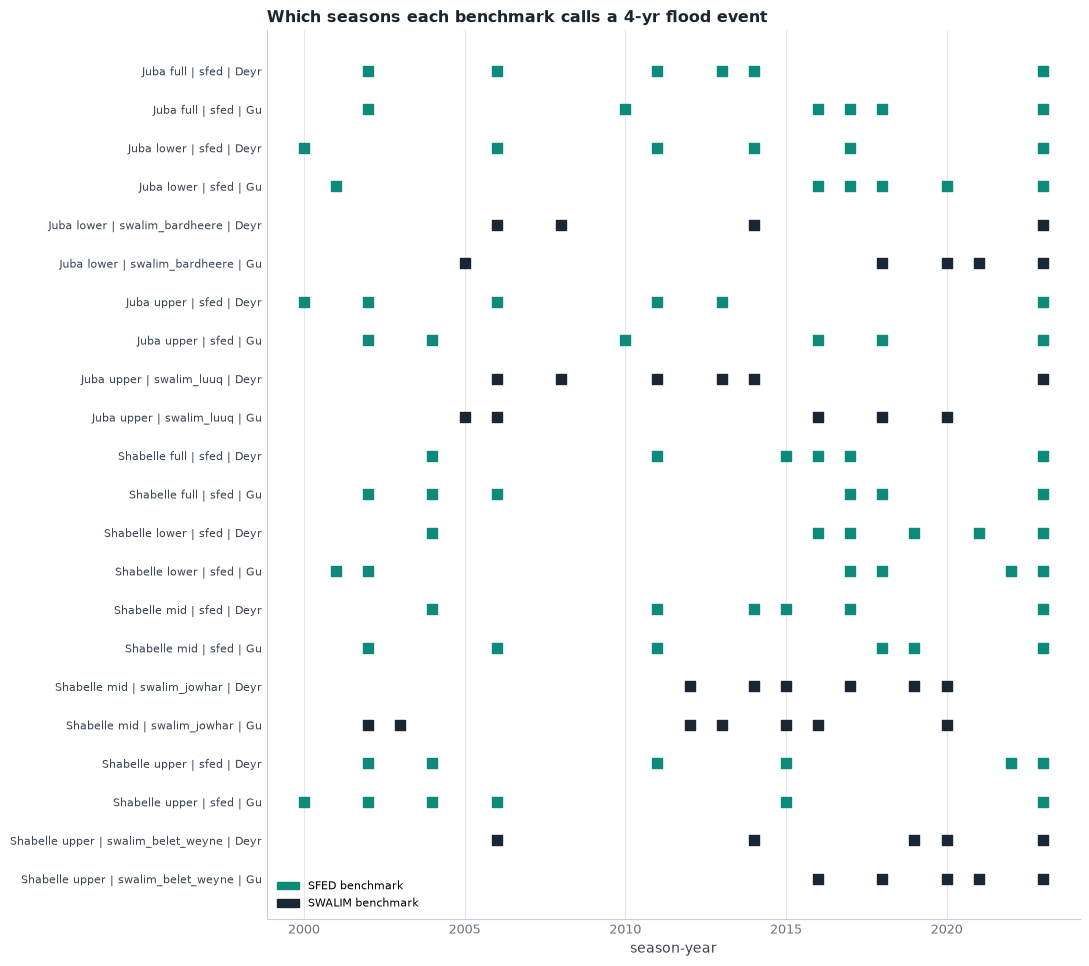

In [7]:
evf = ev.rename("event_years_4yr").reset_index()
evf["label"] = (evf.river.str.capitalize() + " " + evf.segment + " | "
                + evf.benchmark + " | " + evf.season.str.capitalize())
fig, ax = plt.subplots(figsize=(11, 0.38 * len(evf) + 1.4))
for i, r in evf.iterrows():
    color = C_SFED if str(r.benchmark).startswith("sfed") else C_SWALIM
    ax.scatter(r.event_years_4yr, [i] * len(r.event_years_4yr),
               color=color, s=48, marker="s")
ax.set_yticks(range(len(evf)))
ax.set_yticklabels(evf.label, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("season-year")
ax.legend(handles=[mpatches.Patch(color=C_SFED, label="SFED benchmark"),
                   mpatches.Patch(color=C_SWALIM, label="SWALIM benchmark")],
          fontsize=8)
ax.set_title("Which seasons each benchmark calls a 4-yr flood event")
style_ax(ax)
plt.tight_layout()


## The critical check: does Floodscan agree with the gauges?

Overlap of the top-6 (>= 4-yr RP) seasons between the SFED benchmark and the
rank-based SWALIM benchmark at the reach's reference gauge.

In [8]:
def top_years(riv, seg, season, benchmark_prefix):
    sub = bench[(bench.river == riv) & (bench.segment == seg) & (bench.season == season)
                & (bench.benchmark.str.startswith(benchmark_prefix)) & (bench.flood_4yr == 1)]
    return set(sub.year.tolist())

rows = []
for (riv, seg), st in GAUGES.items():
    for season in SEASONS:
        a, b = top_years(riv, seg, season, "sfed"), top_years(riv, seg, season, "swalim")
        if not a or not b:
            continue
        rows.append({"river": riv, "segment": seg, "season": season,
                     "n_agree_of_6": len(a & b), "agree": sorted(a & b),
                     "sfed_only": sorted(a - b), "swalim_only": sorted(b - a)})
pd.DataFrame(rows)


,river,segment,season,n_agree_of_6,agree,sfed_only,swalim_only
0,shabelle,upper,gu,1,[2023],"[2000, 2002, 2004, 2006, 2015]","[2016, 2018, 2020, 2021]"
1,shabelle,upper,deyr,1,[2023],"[2002, 2004, 2011, 2015, 2022]","[2006, 2014, 2019, 2020]"
2,shabelle,mid,gu,1,[2002],"[2006, 2011, 2018, 2019, 2023]","[2003, 2012, 2013, 2015, 2016, 2020]"
3,shabelle,mid,deyr,3,"[2014, 2015, 2017]","[2004, 2011, 2023]","[2012, 2019, 2020]"
4,juba,upper,gu,2,"[2016, 2018]","[2002, 2004, 2010, 2023]","[2005, 2006, 2020]"
5,juba,upper,deyr,4,"[2006, 2011, 2013, 2023]","[2000, 2002]","[2008, 2014]"
6,juba,lower,gu,3,"[2018, 2020, 2023]","[2001, 2016, 2017]","[2005, 2021]"
7,juba,lower,deyr,3,"[2006, 2014, 2023]","[2000, 2011, 2017]",[2008]


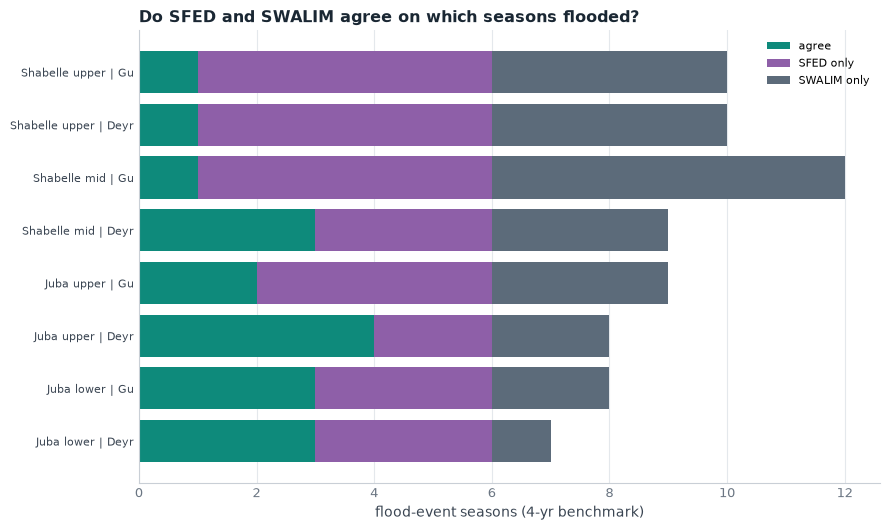

In [9]:
agree_df = pd.DataFrame(rows)
agree_df["label"] = (agree_df.river.str.capitalize() + " " + agree_df.segment
                     + " | " + agree_df.season.str.capitalize())
n_ag = agree_df["n_agree_of_6"]
n_sf = agree_df.sfed_only.str.len()
n_sw = agree_df.swalim_only.str.len()
fig, ax = plt.subplots(figsize=(9, 0.5 * len(agree_df) + 1.4))
y = range(len(agree_df))
ax.barh(y, n_ag, color="#0E8A7B", label="agree")
ax.barh(y, n_sf, left=n_ag, color="#8E5FA8", label="SFED only")
ax.barh(y, n_sw, left=n_ag + n_sf, color="#5C6B7A", label="SWALIM only")
ax.set_yticks(list(y))
ax.set_yticklabels(agree_df.label, fontsize=8)
ax.invert_yaxis()
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xlabel("flood-event seasons (4-yr benchmark)")
ax.set_title("Do SFED and SWALIM agree on which seasons flooded?")
ax.legend(fontsize=8)
style_ax(ax)
plt.tight_layout()


## Findings

1. **Seasonality is cleanly bimodal** (Gu Apr-May, Deyr Oct-Dec) on both
   rivers: the per-season design is right, and any Somalia trigger has
   ~2x the windows of the NGA single-season design.
2. **On the Juba, Floodscan and the gauges broadly agree** (Luuq Deyr: 4 of
   the top-6 seasons shared: 2006, 2011, 2013, 2023). An NGA-style
   SFED-anchored workflow is defensible there.
3. **On the Shabelle they disagree almost completely: only 2023 is shared**
   (1/6 in both seasons at Belet Weyne). SFED's top Deyr years
   (2002, 2004, 2011, 2015, 2022) are not the gauge record's
   (2006, 2014, 2019, 2020, 2023): and the observed record's set matches
   the documented major floods (Deyr 2006, 2019, 2023), while SFED's does
   not. Deyr 2019: a major Belet Weyne flood: never reaches 4-yr RP in
   SFED under any segmentation tried.
4. **Implication for the workflow: the ground-truth benchmark must be
   river-specific.** Juba: SFED (NGA-style) is usable, with SWALIM as
   corroboration. Shabelle: the SWALIM rank-based seasonal benchmark should
   be primary, SFED secondary: anchoring Shabelle thresholds to SFED would
   calibrate the trigger to events that don't match the flood history that
   matters. (Candidate explanations for the divergence: SFED signal in the
   flat, irrigated middle Shabelle driven by local rain/irrigation rather
   than riverine peaks; early-record SFED quality in narrow valleys: are
   worth a follow-up but don't change the design call.)
5. Record starts 1998-01-12, so the 1997/98 El Nino Deyr: the largest
   event in living memory: is outside every series here; all RPs are
   conditioned on a record missing its probable maximum.

**Next step (03):** correlate GRRR/GloFAS gauge reanalysis against BOTH
benchmarks per river/season: lag range widened for the Ethiopian-headwater
travel times: and carry forward whichever benchmark the correlation
supports.

In [10]:
stratus.upload_parquet_to_blob(
    bench, "ds-aa-som-floods/processed/workflow/som_flood_benchmark_seasonal.parquet", stage="dev")
print(f"uploaded som_flood_benchmark_seasonal.parquet ({len(bench)} rows)")


uploaded som_flood_benchmark_seasonal.parquet (547 rows)
